# Analytical formula examples (Wakao-Igarashi-Fujiwara-Kameari Part 1-9)

Runnable demonstrations of `radia.analytical_formulas`, the closed-form
reference layer collecting expressions from the IEE Japan review series
*"Useful Formulas of Analytical Integration in Electromagnetic Field
Computations (Part 1-9)"* (IEE Japan Joint Technical Meeting, 2002-2007).

Each section runs a short script that evaluates a closed form and checks it
against an independent reference (brute-force sweep, asymptote, scipy.special,
or another Radia path), saving its figure (committed alongside this notebook).

For the full PDF<->code cross-reference table see
[`docs/analytical_formulas.md`](../analytical_formulas.md). Source:
[`src/radia/analytical_formulas/`](../../src/radia/analytical_formulas/);
tests: `tests/analytical_formulas/`.

Promoted from `examples/analytical_formulas/` on 2026-06-26 (the 12 scripts are
embedded verbatim below; the `src`-tree `sys.path` shims were dropped since
`radia` is installed).

## Ellipsoid demagnetization factor and torque

Demagnetization factor and torque of a rotational ellipsoid, swept over aspect ratio. (Part 5 sec.5, eq 39-44)

*(source: `ellipsoid_demag_torque.py`)*

c/a       N_x = N_y     N_z         sum
--------------------------------------------------
 0.100    0.069598     0.860804    1.000000
 0.200    0.124758     0.750484    1.000000
 0.500    0.236400     0.527200    1.000000
 1.000    0.333333     0.333333    1.000000
 2.000    0.413218     0.173564    1.000000
 5.000    0.472090     0.055821    1.000000
10.000    0.489857     0.020286    1.000000

Torque scan (c/a = 5 prolate, chi_r = 999, H_0 = 1000 A/m):
  T_z(alpha=0)        = -0.0000e+00 N m  (expect 0)
  T_z(alpha=pi/4)     = -2.0365e-04 N m  (expect < 0)
  T_z(alpha=pi/2)     = -2.4955e-20 N m  (expect 0)
  T_z(alpha=3 pi / 4) = 2.0365e-04 N m  (expect > 0)



Saved: ellipsoid_demag_torque.png


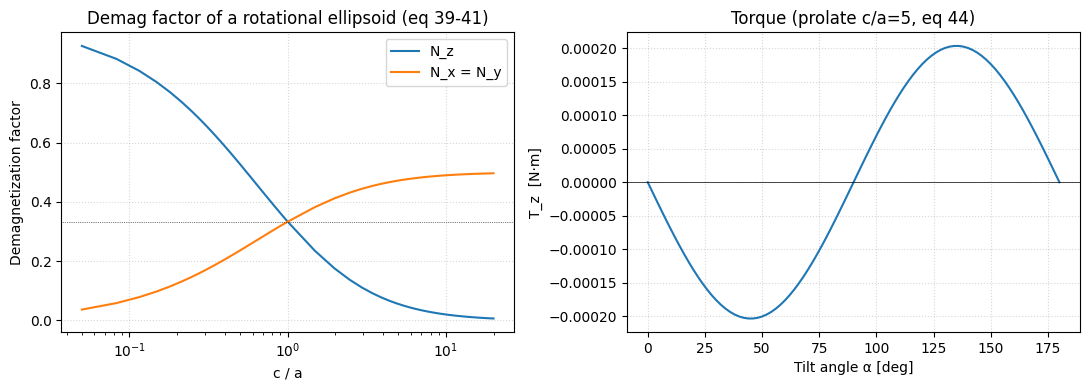

In [1]:
"""Rotational ellipsoid: demagnetization factor and torque.

Reference: Part 5 (SA-04-44 / RM-04-68, 2004), eq 39-44.

Two scans:
  1. N_z(c/a) over the prolate (c > a) and oblate (c < a) ranges.
     Reproduces Fig. 7 of the PDF.
  2. Torque T_z(alpha) for a fixed prolate (c/a = 5) at chi_r = 999;
     should be sinusoidal with sign convention "alpha -> 0 is
     restoring" (T_z < 0 for alpha in (0, pi/2)).
"""

from __future__ import annotations

import math
import os
import sys

import numpy as np

from radia.analytical_formulas import (
    demag_factor_rotational,
    ellipsoid_torque,
)


def main() -> None:
    # ----- N_z scan over c/a -----
    ratios = np.concatenate([
        np.linspace(0.05, 1.0, 30),
        np.linspace(1.0, 20.0, 40),
    ])
    Nz_arr = np.array([demag_factor_rotational(r, 1.0)[2] for r in ratios])

    print("c/a       N_x = N_y     N_z         sum")
    print("-" * 50)
    for r in (0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0):
        Nx, _, Nz = demag_factor_rotational(r, 1.0)
        print(f"{r:6.3f}    {Nx:.6f}     {Nz:.6f}    {Nx+Nx+Nz:.6f}")

    # ----- Torque sweep -----
    a, c = 0.01, 0.05            # prolate, c/a = 5
    chi_r = 999.0
    H0 = 1000.0
    alphas = np.linspace(0.0, math.pi, 91)
    Tz = np.array([
        ellipsoid_torque(H0, alpha, chi_r=chi_r, a=a, c=c) for alpha in alphas
    ])
    print()
    print("Torque scan (c/a = 5 prolate, chi_r = 999, H_0 = 1000 A/m):")
    print(f"  T_z(alpha=0)        = {Tz[0]:.4e} N m  (expect 0)")
    print(f"  T_z(alpha=pi/4)     = {Tz[len(alphas)//4]:.4e} N m  (expect < 0)")
    print(f"  T_z(alpha=pi/2)     = {Tz[len(alphas)//2]:.4e} N m  (expect 0)")
    print(f"  T_z(alpha=3 pi / 4) = {Tz[3*len(alphas)//4]:.4e} N m  (expect > 0)")

    # Optional plot.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(ratios, Nz_arr, label="N_z")
    axes[0].plot(ratios, 0.5 * (1.0 - Nz_arr), label="N_x = N_y")
    axes[0].axhline(1.0 / 3.0, color="k", lw=0.5, ls=":")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("c / a")
    axes[0].set_ylabel("Demagnetization factor")
    axes[0].set_title("Demag factor of a rotational ellipsoid (eq 39-41)")
    axes[0].legend()
    axes[0].grid(True, ls=":", alpha=0.5)

    axes[1].plot(np.degrees(alphas), Tz)
    axes[1].set_xlabel("Tilt angle α [deg]")
    axes[1].set_ylabel("T_z  [N·m]")
    axes[1].set_title("Torque (prolate c/a=5, eq 44)")
    axes[1].grid(True, ls=":", alpha=0.5)
    axes[1].axhline(0.0, color="k", lw=0.5)

    fig.tight_layout()
    out = "ellipsoid_demag_torque.png"
    fig.savefig(out, dpi=150)
    print(f"\nSaved: {out}")

main()


## AC time-locus ellipse axes

Major/minor axis of the time-locus ellipse traced by an AC phasor; closed form vs brute-force time sweep. (Part 5 sec.4, eq 29-37)

*(source: `ac_locus_demo.py`)*

case                     |B|_max (analytic)    |B|_max (sweep)    |B|_min (analytic)    |B|_min (sweep)
-------------------------------------------------------------------------------------------------------
linear (along x)                   1.000000           1.000000              0.000000           0.000000
circular (xy)                      1.000000           1.000000              1.000000           1.000000
elliptical 2:1                     2.000000           2.000000              1.000000           1.000000
tilted 3D ellipse                  0.734619           0.734619              0.304689           0.304689
random sample                      2.989383           2.989383              2.027890           2.027890

Saved: ac_locus_demo.png


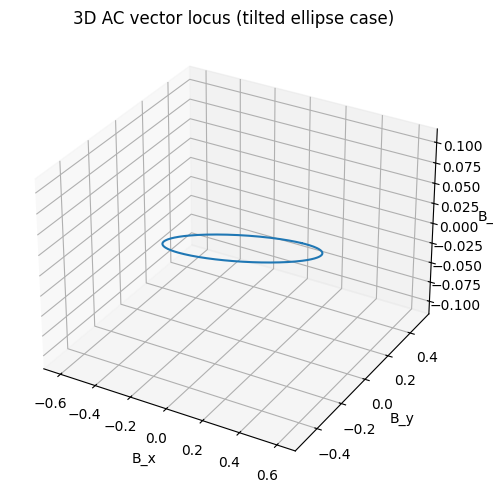

In [2]:
"""Major / minor axis of an AC vector quantity's time-locus ellipse.

Reference: Part 5 (SA-04-44 / RM-04-68, 2004), eq 29-37.

The closed form is verified against a brute-force time sweep for a
randomly-chosen 3-component complex phasor. Cross-section: a noisy
"flux-density" sample point in an AC eddy-current run might give
B_x = 0.6 + 0.1j, B_y = -0.4 + 0.3j, B_z = 0.1 - 0.05j (in T).
"""

from __future__ import annotations

import os
import sys

import numpy as np

from radia.analytical_formulas import ac_locus_axes


def brute_force_axes(B: np.ndarray, n_t: int = 20000):
    """Sample |b(t)| on a fine time grid and return its (max, min)."""
    omega_t = np.linspace(0.0, 2.0 * np.pi, n_t, endpoint=False)
    bt = np.real(B[None, :] * np.exp(1j * omega_t)[:, None])  # (n_t, 3)
    mag = np.linalg.norm(bt, axis=1)
    return float(mag.max()), float(mag.min())


def main() -> None:
    rng = np.random.default_rng(seed=2025)

    cases = {
        "linear (along x)": np.array([1.0, 0.0, 0.0], dtype=complex),
        "circular (xy)":     np.array([1.0, 1j, 0.0]),
        "elliptical 2:1":    np.array([2.0, 1j, 0.0]),
        "tilted 3D ellipse": np.array([0.6 + 0.1j, -0.4 + 0.3j, 0.1 - 0.05j]),
        "random sample":     rng.standard_normal(3) + 1j * rng.standard_normal(3),
    }

    hdr = f'{"case":<22} {"|B|_max (analytic)":>20} {"|B|_max (sweep)":>18}  {"|B|_min (analytic)":>20} {"|B|_min (sweep)":>18}'
    print(hdr)
    print("-" * len(hdr))
    for name, B in cases.items():
        mx_an, mn_an = ac_locus_axes(B)
        mx_bf, mn_bf = brute_force_axes(B)
        print(
            f"{name:<22} {mx_an:>20.6f} {mx_bf:>18.6f}  "
            f"{mn_an:>20.6f} {mn_bf:>18.6f}"
        )

    # Optional plot of the locus for the tilted case.
    try:
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return
    B = cases["tilted 3D ellipse"]
    omega_t = np.linspace(0.0, 2.0 * np.pi, 200)
    bt = np.real(B[None, :] * np.exp(1j * omega_t)[:, None])
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(bt[:, 0], bt[:, 1], bt[:, 2])
    ax.set_xlabel("B_x")
    ax.set_ylabel("B_y")
    ax.set_zlabel("B_z")
    ax.set_title("3D AC vector locus (tilted ellipse case)")
    fig.tight_layout()
    out = "ac_locus_demo.png"
    fig.savefig(out, dpi=150)
    print(f"\nSaved: {out}")

main()


## Cylindrical / spherical shell shielding

Static shielding factor of cylindrical and spherical magnetic shells in a uniform field; thin-shell asymptote check. (Part 1 sec.5, eq 23-24)

*(source: `cylinder_sphere_shielding.py`)*

S vs mu_r (t/b = 0.05)
      mu_r        S_cyl        S_sph
      1.00   1.0000e+00   1.0000e+00
      7.04   8.8789e-01   8.5897e-01
     49.54   4.6314e-01   3.9884e-01
    348.64   1.0583e-01   8.3427e-02
   2453.75   1.6458e-02   1.2705e-02
  17269.83   2.3702e-03   1.8238e-03
 100000.00   4.1010e-04   3.1542e-04

S vs t/b (mu_r = 1000)
     t/b        S_cyl        S_sph
  0.0010   6.6722e-01   6.0072e-01
  0.1028   2.0130e-02   1.5968e-02
  0.2047   1.0790e-02   8.9923e-03
  0.3065   7.6623e-03   6.7199e-03
  0.4083   6.1289e-03   5.6547e-03
  0.5000   5.3156e-03   5.1267e-03



Saved: cylinder_sphere_shielding.png


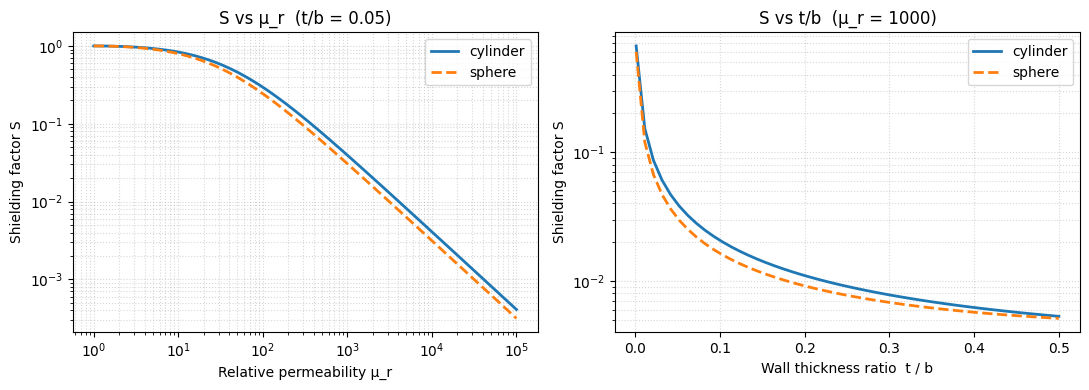

In [3]:
"""Magnetic shielding factor of cylindrical and spherical shells.

Reference: Part 1 (SA-02-28 / RM-02-64, 2002), eq 23-24.

Sweeps over relative permeability mu_r at fixed wall thickness, and
over wall thickness at fixed mu_r. Both shapes are compared on the
same axes.
"""

from __future__ import annotations

import os
import sys

import numpy as np

from radia.analytical_formulas import (
    shielding_factor_cylinder,
    shielding_factor_sphere,
)


def main() -> None:
    # -----------------------------------------------------------------
    # 1) Sweep mu_r at fixed thickness ratio t/b = 0.05.
    # -----------------------------------------------------------------
    b = 1.0
    t_over_b = 0.05
    a = b * (1.0 - t_over_b)
    mu_rs = np.geomspace(1.0, 1.0e5, 60)
    S_cyl = np.array([shielding_factor_cylinder(a, b, mu) for mu in mu_rs])
    S_sph = np.array([shielding_factor_sphere(a, b, mu) for mu in mu_rs])

    print("S vs mu_r (t/b = 0.05)")
    print(f"{'mu_r':>10} {'S_cyl':>12} {'S_sph':>12}")
    for k in (0, 10, 20, 30, 40, 50, 59):
        print(f"{mu_rs[k]:>10.2f} {S_cyl[k]:>12.4e} {S_sph[k]:>12.4e}")

    # -----------------------------------------------------------------
    # 2) Sweep wall thickness at fixed mu_r = 1000.
    # -----------------------------------------------------------------
    mu_r = 1000.0
    ts = np.linspace(0.001, 0.5, 50)
    S_cyl_t = np.array([shielding_factor_cylinder(b * (1 - t), b, mu_r) for t in ts])
    S_sph_t = np.array([shielding_factor_sphere(b * (1 - t), b, mu_r) for t in ts])

    print()
    print("S vs t/b (mu_r = 1000)")
    print(f"{'t/b':>8} {'S_cyl':>12} {'S_sph':>12}")
    for k in (0, 10, 20, 30, 40, 49):
        print(f"{ts[k]:>8.4f} {S_cyl_t[k]:>12.4e} {S_sph_t[k]:>12.4e}")

    # -----------------------------------------------------------------
    # Optional plots.
    # -----------------------------------------------------------------
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].loglog(mu_rs, S_cyl, label="cylinder", lw=2)
    axes[0].loglog(mu_rs, S_sph, label="sphere", lw=2, ls="--")
    axes[0].set_xlabel("Relative permeability μ_r")
    axes[0].set_ylabel("Shielding factor S")
    axes[0].set_title(f"S vs μ_r  (t/b = {t_over_b:.2f})")
    axes[0].grid(True, ls=":", alpha=0.5, which="both")
    axes[0].legend()

    axes[1].semilogy(ts, S_cyl_t, label="cylinder", lw=2)
    axes[1].semilogy(ts, S_sph_t, label="sphere", lw=2, ls="--")
    axes[1].set_xlabel("Wall thickness ratio  t / b")
    axes[1].set_ylabel("Shielding factor S")
    axes[1].set_title(f"S vs t/b  (μ_r = {mu_r:.0f})")
    axes[1].grid(True, ls=":", alpha=0.5, which="both")
    axes[1].legend()

    fig.tight_layout()
    out = "cylinder_sphere_shielding.png"
    fig.savefig(out, dpi=150)
    print(f"\nSaved: {out}")

main()


## 2D field of a rectangular magnet

2D field of a uniformly magnetised rectangular bar; far-field 2D dipole law check. (Part 2 sec.2, eq 2-3)

*(source: `rect_magnet_2d_field.py`)*

Bar: 2a x 2b = 40.0 mm x 20.0 mm, M = (9.549e+05, 0.000e+00) A/m
mu_0 * M_x = 1.2000 T
B at center: (0.8458, -0.0000e+00) T
  Cross-section demag along x:  N_x = 0.2952

  r [m]    |B|_analytic [T]    |B|_dipole-law [T]    rel err
   0.050   6.8699e-02        6.1115e-02        1.241e-01
   0.100   1.5742e-02        1.5279e-02        3.034e-02
   0.300   1.7033e-03        1.6977e-03        3.338e-03
   1.000   1.5283e-04        1.5279e-04        3.000e-04
   5.000   6.1116e-06        6.1115e-06        1.200e-05



Saved: rect_magnet_2d_field.png


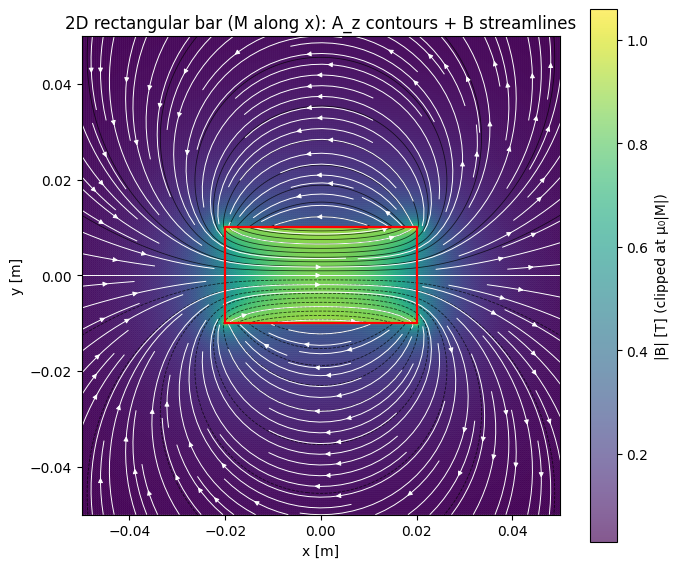

In [4]:
"""2D field of a uniformly magnetised rectangular bar.

Reference: Part 2 (SA-03-08 / RM-03-08, 2003), eq 2-3.

Plots vector potential contours and B-field streamlines around a 2 a x 2 b
bar magnetised along x. Far-field 2D dipole law is verified along the
horizontal axis.
"""

from __future__ import annotations

import math
import os
import sys

import numpy as np

from radia.analytical_formulas import rect_magnet_2d_A, rect_magnet_2d_B
from radia.analytical_formulas.rect_magnet_2d import MU_0


def main() -> None:
    # 4 cm x 2 cm bar, M_x = 1.2 / mu_0 ~ 9.55e5 A/m (typical NdFeB).
    a, b = 0.02, 0.01
    M = (1.2 / MU_0, 0.0)
    print(f"Bar: 2a x 2b = {2*a*1000:.1f} mm x {2*b*1000:.1f} mm, "
          f"M = ({M[0]:.3e}, {M[1]:.3e}) A/m")
    print(f"mu_0 * M_x = {MU_0 * M[0]:.4f} T")

    # Demag-factor check at center.
    B_c = rect_magnet_2d_B([0.0, 0.0], a, b, M=M)
    print(f"B at center: ({B_c[0]:.4f}, {B_c[1]:.4e}) T")
    print(f"  Cross-section demag along x:  N_x = "
          f"{1.0 - B_c[0] / (MU_0 * M[0]):.4f}")

    # Far-field 2D dipole comparison along x-axis.
    rs = np.array([0.05, 0.1, 0.3, 1.0, 5.0])
    print(f"\n  r [m]    |B|_analytic [T]    |B|_dipole-law [T]    rel err")
    m_2D = M[0] * 4.0 * a * b
    for r in rs:
        B = rect_magnet_2d_B(np.array([r, 0.0]), a, b, M=M)
        Bmag = float(np.linalg.norm(B))
        # 2D dipole on its axis (M along x, point on +x axis):
        # |B_x| = mu_0 * m / (2 pi r**2)
        Bd = MU_0 * m_2D / (2.0 * math.pi * r * r)
        print(f"  {r:6.3f}   {Bmag:.4e}        {Bd:.4e}        "
              f"{abs(Bmag - Bd) / Bd:.3e}")

    # Optional 2D plot.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    grid = np.linspace(-0.05, 0.05, 240)
    X, Y = np.meshgrid(grid, grid)
    points = np.stack([X.ravel(), Y.ravel()], axis=-1)
    A = rect_magnet_2d_A(points, a, b, M=M).reshape(X.shape)
    B = rect_magnet_2d_B(points, a, b, M=M).reshape(X.shape + (2,))
    Bmag = np.linalg.norm(B, axis=-1)

    fig, ax = plt.subplots(figsize=(7, 6))
    cs = ax.contour(X, Y, A, levels=21, colors="k", linewidths=0.6, alpha=0.7)
    pcm = ax.pcolormesh(X, Y, np.minimum(Bmag, MU_0 * abs(M[0])), shading="gouraud",
                        cmap="viridis", alpha=0.65)
    ax.streamplot(X, Y, B[..., 0], B[..., 1], color="white",
                  density=1.5, linewidth=0.7, arrowsize=0.7)
    rect_x = [-a, +a, +a, -a, -a]
    rect_y = [-b, -b, +b, +b, -b]
    ax.plot(rect_x, rect_y, "r-", lw=1.6)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title("2D rectangular bar (M along x): A_z contours + B streamlines")
    fig.colorbar(pcm, ax=ax, label="|B| [T] (clipped at μ₀|M|)")
    fig.tight_layout()
    out = "rect_magnet_2d_field.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Thin rectangular plate eddy current

Eddy current in a thin rectangular plate under a slowly-varying perpendicular B; streamlines + cross-sections. (Part 1 sec.6.1, eq 26-27)

*(source: `rectangular_plate_eddy.py`)*

Plate: 2 a x 2 b = 0.200 m x 0.200 m
sigma = 5.00e+07 S/m, dB_z/dt = 1.0 T/s
Series truncation n_terms = 80

Boundary check (T_z and J . n should both be small):
  T_z(a, 0)            = 1.582e-12
  T_z(0, b)            = -7.872e-03
  J_x(a, 0.05)         = 2.440e-11
  J_y(0.05, b)         = -3.495e-01

J_x(0, y) along the symmetry axis x = 0:
   y [m]      J_x [A/m^2]
   0.000       0.0000e+00
   0.020       1.2682e+05
   0.040       2.6457e+05
   0.060       4.2397e+05
   0.080       6.1477e+05
   0.100       8.4412e+05



Saved: rectangular_plate_eddy.png


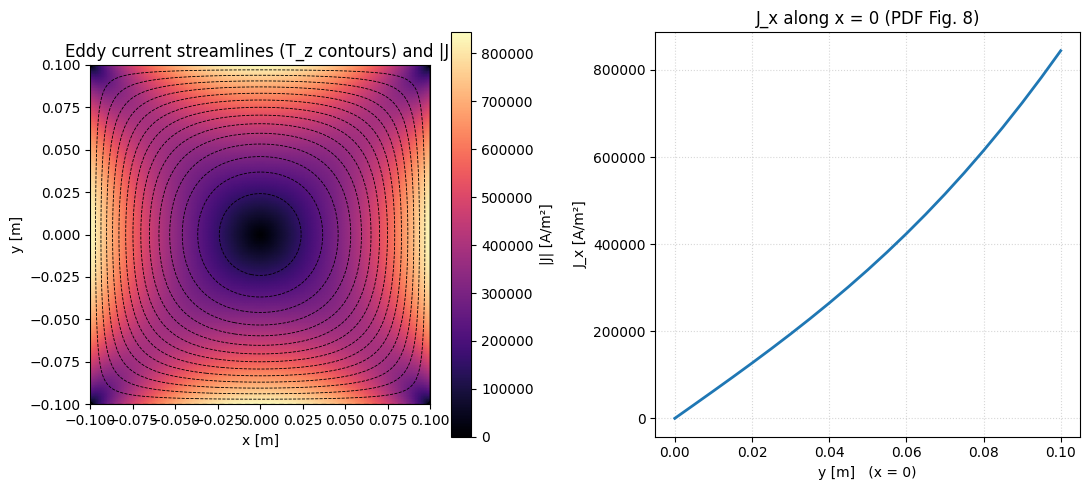

In [5]:
"""Eddy current in a thin rectangular plate.

Reference: Part 1 (SA-02-28 / RM-02-64, 2002), eq 26-27.
Source: Weissenburger and Christensen (PPPL-1517, 1979).

Reproduces Figs. 7-8 of the PDF: T_z contours = streamlines, plus J_x
along x = 0.
"""

from __future__ import annotations

import os
import sys

import numpy as np

from radia.analytical_formulas import plate_eddy_J, plate_eddy_T


def main() -> None:
    # Square plate as in PDF Fig. 7: 2 a = 2 b = 0.2 m, copper, dB/dt = 1 T/s.
    a = b = 0.1
    sigma = 5.0e7
    Bdot = 1.0
    n_terms = 80
    print(f"Plate: 2 a x 2 b = {2*a:.3f} m x {2*b:.3f} m")
    print(f"sigma = {sigma:.2e} S/m, dB_z/dt = {Bdot} T/s")
    print(f"Series truncation n_terms = {n_terms}")

    # Boundary integrity.
    print()
    print("Boundary check (T_z and J . n should both be small):")
    print(f"  T_z(a, 0)            = "
          f"{plate_eddy_T([a, 0.0], a, b, sigma, Bdot, n_terms=n_terms):.3e}")
    print(f"  T_z(0, b)            = "
          f"{plate_eddy_T([0.0, b], a, b, sigma, Bdot, n_terms=n_terms):.3e}")
    print(f"  J_x(a, 0.05)         = "
          f"{plate_eddy_J([a, 0.05], a, b, sigma, Bdot, n_terms=n_terms)[0]:.3e}")
    print(f"  J_y(0.05, b)         = "
          f"{plate_eddy_J([0.05, b], a, b, sigma, Bdot, n_terms=n_terms)[1]:.3e}")

    # J_x along x = 0 vs y (Fig. 8 of the PDF).
    ys = np.linspace(0.0, b, 21)
    Jx = np.array([
        plate_eddy_J([0.0, y], a, b, sigma, Bdot, n_terms=n_terms)[0]
        for y in ys
    ])
    print()
    print("J_x(0, y) along the symmetry axis x = 0:")
    print(f"{'y [m]':>8} {'J_x [A/m^2]':>16}")
    for y, j in zip(ys[::4], Jx[::4]):
        print(f"{y:>8.3f} {j:>16.4e}")

    # Plots.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    nx, ny = 121, 121
    x = np.linspace(-a, +a, nx)
    y = np.linspace(-b, +b, ny)
    X, Y = np.meshgrid(x, y)
    pts = np.stack([X.ravel(), Y.ravel()], axis=-1)
    T = plate_eddy_T(pts, a, b, sigma, Bdot, n_terms=n_terms).reshape(X.shape)
    J = plate_eddy_J(pts, a, b, sigma, Bdot, n_terms=n_terms).reshape(X.shape + (2,))
    Jmag = np.linalg.norm(J, axis=-1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    cs = axes[0].contour(X, Y, T, levels=15, colors="k", linewidths=0.6)
    pcm = axes[0].pcolormesh(X, Y, Jmag, cmap="magma", shading="gouraud")
    axes[0].set_aspect("equal")
    axes[0].set_xlabel("x [m]")
    axes[0].set_ylabel("y [m]")
    axes[0].set_title("Eddy current streamlines (T_z contours) and |J|")
    fig.colorbar(pcm, ax=axes[0], label="|J| [A/m²]")

    axes[1].plot(ys, Jx, lw=2)
    axes[1].set_xlabel("y [m]   (x = 0)")
    axes[1].set_ylabel("J_x [A/m²]")
    axes[1].set_title("J_x along x = 0 (PDF Fig. 8)")
    axes[1].grid(True, ls=":", alpha=0.5)

    fig.tight_layout()
    out = "rectangular_plate_eddy.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Fabri solenoid axial field

Central- and axial-field profile of a rectangular-section solenoid; long-coil limit B0 -> mu_0 J (a2-a1). (Part 4 sec.4, eq 26-27)

*(source: `solenoid_axial_field.py`)*

Geometry: a_1 = 50 mm, a_2 = 100 mm, J = 1.00e+07 A/m**2
Long-coil limit B_inf = mu_0 J (a_2 - a_1) = 0.6283 T

b [m]   alpha   beta    F(alpha, beta)   B_0 [T]   B_0 / B_inf
  0.001   2.000    0.020   0.01386        0.0087   0.0139
  0.010   2.000    0.200   0.13716        0.0862   0.1372
  0.050   2.000    1.000   0.56226        0.3533   0.5623
  0.100   2.000    2.000   0.80032        0.5029   0.8003
  0.500   2.000   10.000   0.98856        0.6211   0.9886
  5.000   2.000   100.000   0.99988        0.6282   0.9999

Saved: solenoid_axial_field.png


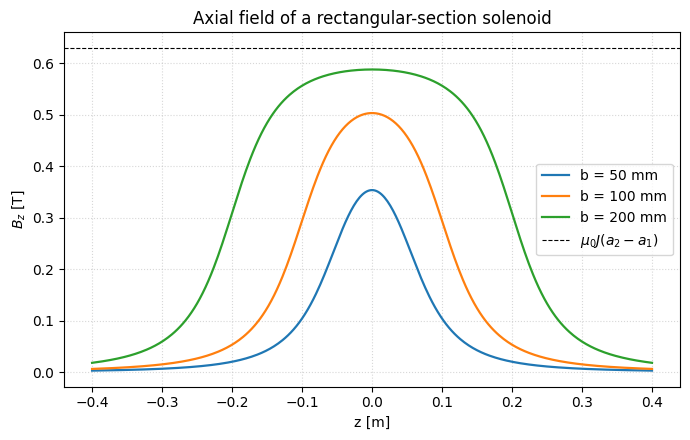

In [6]:
"""Solenoid axial-field profile and Fabri form factor.

Reference: Part 4 (SA-04-1 / RM-04-1, 2004), eq 25-29.
            Montgomery, "Solenoid Magnet Design" (Wiley, 1969).

Plots ``B_z(z)`` along the symmetry axis of a finite rectangular-
section solenoid and reports the central-field Fabri factor
``F(alpha, beta)``. Verifies the long-coil limit
``B_0 -> mu_0 J (a_2 - a_1)``.
"""

from __future__ import annotations

import os
import sys

import numpy as np

from radia.analytical_formulas import (
    fabri_F,
    solenoid_axial_field,
    solenoid_central_field,
)
from radia.analytical_formulas.solenoid_central import MU_0


def main() -> None:
    a1, a2 = 0.05, 0.10        # 50 mm inner, 100 mm outer
    J = 1.0e7                  # 10 MA / m**2
    print(f"Geometry: a_1 = {a1*1000:.0f} mm, a_2 = {a2*1000:.0f} mm, "
          f"J = {J:.2e} A/m**2")
    print(f"Long-coil limit B_inf = mu_0 J (a_2 - a_1) = "
          f"{MU_0 * J * (a2 - a1):.4f} T")
    print()
    print("b [m]   alpha   beta    F(alpha, beta)   B_0 [T]   B_0 / B_inf")
    for b in (0.001, 0.01, 0.05, 0.1, 0.5, 5.0):
        alpha = a2 / a1
        beta = b / a1
        F = fabri_F(alpha, beta)
        B0 = solenoid_central_field(a1, a2, b, J)
        ratio = B0 / (MU_0 * J * (a2 - a1))
        print(f"  {b:.3f}   {alpha:.3f}   {beta:6.3f}   {F:.5f}        "
              f"{B0:.4f}   {ratio:.4f}")

    # Axial profile.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    fig, ax = plt.subplots(figsize=(7, 4.5))
    z = np.linspace(-0.4, 0.4, 401)
    for b in (0.05, 0.1, 0.2):
        Bz = solenoid_axial_field(z, a1, a2, b, J)
        ax.plot(z, Bz, lw=1.6, label=f"b = {b*1000:.0f} mm")
    ax.axhline(MU_0 * J * (a2 - a1), color="k", ls="--", lw=0.8,
               label=r"$\mu_0 J (a_2 - a_1)$")
    ax.set_xlabel("z [m]")
    ax.set_ylabel(r"$B_z$ [T]")
    ax.set_title("Axial field of a rectangular-section solenoid")
    ax.legend()
    ax.grid(True, ls=":", alpha=0.5)
    fig.tight_layout()
    out = "solenoid_axial_field.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Three-phase line far field

Three-phase line far-field decay: triangle (1/r^2), planar (1/r^2, sqrt3 prefactor), helical (exp(-2 pi r/p)). (Part 4 sec.5, Part 5 sec.3)

*(source: `three_phase_line_field.py`)*

Three-phase line: a = d = 50 mm, I_rms = 1000 A, I_peak = 1414.2 A

   r [m]   |B|_tri rigorous    tri formula  |B|_plan rigorous   plan formula
    0.10    3.6365e-03      2.1213e-03        3.3993e-03     2.4495e-03
    0.29    2.9293e-04      2.4884e-04        2.9746e-04     2.8734e-04
    0.85    3.0909e-05      2.9191e-05        3.3843e-05     3.3707e-05
    2.49    3.4931e-06      3.4243e-06        3.9559e-06     3.9540e-06
    7.27    4.0445e-07      4.0169e-07        4.6386e-07     4.6383e-07
   21.22    4.7232e-08      4.7120e-08        5.4410e-08     5.4410e-08
   50.00    8.4938e-09      8.4853e-09        9.7980e-09     9.7980e-09

Helical three-phase, p = 0.5 m  (a << p << r regime):
   r [m]  |B|_far (helical)
    0.10    2.6648e-04
    0.50    7.8196e-07
    1.00    1.0326e-09
    2.00    2.5462e-15
    4.00    2.1896e-26



Saved: three_phase_line_field.png


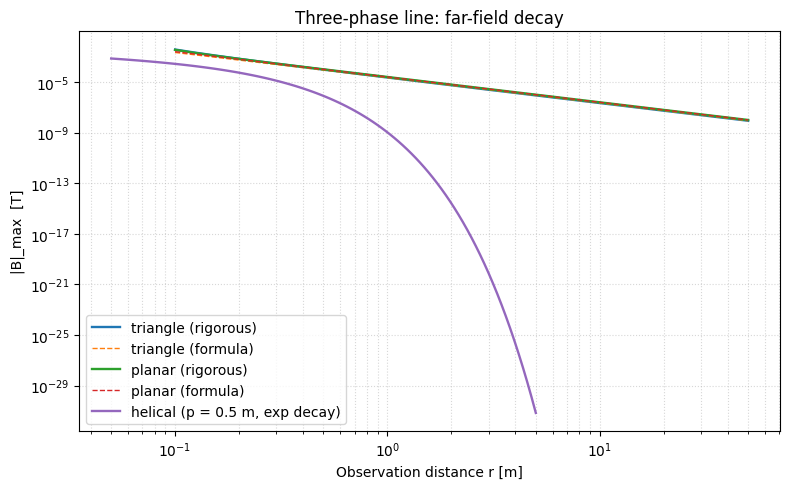

In [7]:
"""Three-phase line magnetic field: triangle, planar, helical.

Reference: Part 4 §5 (SA-04-1 / RM-04-1, 2004) eq 30-44, and
           Part 5 §3 (SA-04-44 / RM-04-68, 2004) eq 11-28.

Compares the triangle and coplanar arrangement far-field formulas
against direct Biot-Savart sums and shows the exponential decay of a
helical three-phase line.
"""

from __future__ import annotations

import math
import os
import sys

import numpy as np

from radia.analytical_formulas import (
    ac_locus_axes,
    balanced_three_phase_currents,
    field_xy,
    helical_far_field_amplitude,
    planar_far_field_amplitude,
    planar_positions,
    triangle_far_field_amplitude,
    triangle_positions,
)


def main() -> None:
    a = 0.05            # 50 mm radius (triangle / spacing for planar = 50 mm)
    I_rms = 1000.0      # 1 kA RMS
    I_peak = math.sqrt(2.0) * I_rms
    rs = np.geomspace(0.1, 50.0, 30)

    # ----- Triangle vs planar ---------------------------------------
    print(f"Three-phase line: a = d = {a*1000:.0f} mm, "
          f"I_rms = {I_rms:.0f} A, I_peak = {I_peak:.1f} A")
    print()
    print(f"{'r [m]':>8} {'|B|_tri rigorous':>18} {'tri formula':>14} "
          f"{'|B|_plan rigorous':>18} {'plan formula':>14}")
    bmax_tri = np.zeros_like(rs)
    bmax_plan = np.zeros_like(rs)
    f_tri = np.zeros_like(rs)
    f_plan = np.zeros_like(rs)
    pos_tri = triangle_positions(a)
    pos_plan = planar_positions(a)
    currents = balanced_three_phase_currents(I_peak)
    for k, r in enumerate(rs):
        B_tri = field_xy(pos_tri, currents, [r, 0.0])
        bmax_tri[k], _ = ac_locus_axes([B_tri[0], B_tri[1], 0.0])
        B_plan = field_xy(pos_plan, currents, [r, 0.0])
        bmax_plan[k], _ = ac_locus_axes([B_plan[0], B_plan[1], 0.0])
        f_tri[k] = triangle_far_field_amplitude(r, I_peak, a)
        f_plan[k] = planar_far_field_amplitude(r, I_peak, a)
    for k in (0, 5, 10, 15, 20, 25, 29):
        print(f"  {rs[k]:6.2f}    {bmax_tri[k]:.4e}      {f_tri[k]:.4e}   "
              f"     {bmax_plan[k]:.4e}     {f_plan[k]:.4e}")

    # ----- Helical exp decay ----------------------------------------
    print()
    print("Helical three-phase, p = 0.5 m  (a << p << r regime):")
    print(f"{'r [m]':>8} {'|B|_far (helical)':>18}")
    for r in (0.1, 0.5, 1.0, 2.0, 4.0):
        B_helix = helical_far_field_amplitude(r, I_peak, a=a, p=0.5)
        print(f"  {r:6.2f}    {B_helix:.4e}")

    # ----- Plot -----------------------------------------------------
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(rs, bmax_tri, "-", lw=1.7, label="triangle (rigorous)")
    ax.loglog(rs, f_tri, "--", lw=1.0, label="triangle (formula)")
    ax.loglog(rs, bmax_plan, "-", lw=1.7, label="planar (rigorous)")
    ax.loglog(rs, f_plan, "--", lw=1.0, label="planar (formula)")
    rs_fine = np.geomspace(0.05, 5.0, 100)
    Bhel = np.array([helical_far_field_amplitude(r, I_peak, a, 0.5) for r in rs_fine])
    ax.loglog(rs_fine, Bhel, "-", lw=1.7,
              label="helical (p = 0.5 m, exp decay)")
    ax.set_xlabel("Observation distance r [m]")
    ax.set_ylabel("|B|_max  [T]")
    ax.set_title("Three-phase line: far-field decay")
    ax.legend()
    ax.grid(True, ls=":", alpha=0.5, which="both")
    fig.tight_layout()
    out = "three_phase_line_field.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## K(k), E(k) Hastings accuracy

Absolute-error plot of degree-2 vs degree-4 Hastings approximations of K(k), E(k) vs scipy.special. (Part 3 sec.3, Tables 1-2)

*(source: `elliptic_integrals_accuracy.py`)*

     k    K err deg2    K err deg4    E err deg2    E err deg4
  0.00      2.68e-08      4.90e-12      2.68e-08      5.10e-12
  0.10      4.64e-06      6.02e-09      6.11e-06      7.04e-09
  0.30      2.70e-05      5.96e-09      3.54e-05      6.95e-09
  0.50      1.66e-05      9.85e-09      2.15e-05      1.15e-08
  0.70      2.83e-05      6.93e-09      3.72e-05      8.09e-09
  0.90      2.49e-05      1.34e-08      3.28e-05      1.57e-08
  0.95      2.27e-05      9.63e-09      2.94e-05      1.13e-08
  0.99      2.77e-05      1.34e-08      3.64e-05      1.57e-08



Saved: elliptic_integrals_accuracy.png


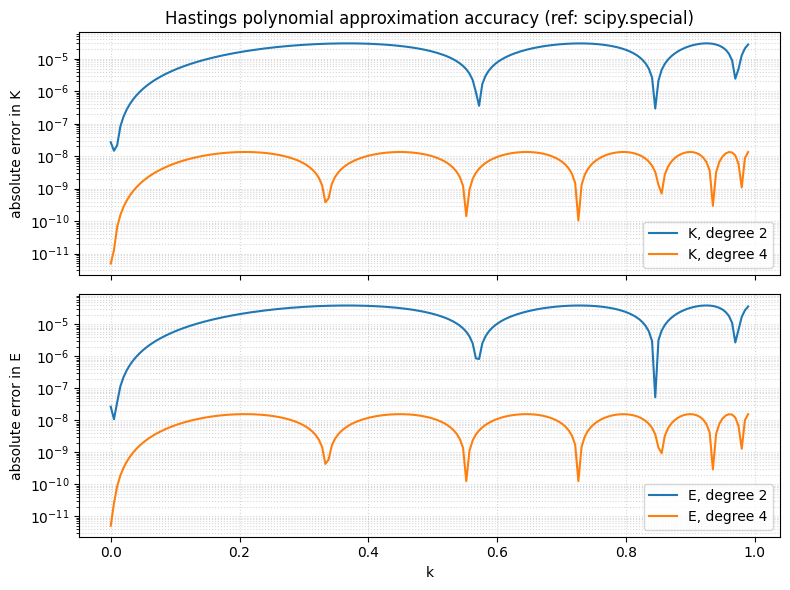

In [8]:
"""Hastings polynomial approximations for K(k), E(k): accuracy table.

Reference: Part 3 §3 (SA-03-52 / RM-03-54, 2003), eq 13 + Tables 1-2.

Compares the degree-2 and degree-4 Hastings polynomial approximations
against ``scipy.special.ellipk`` / ``ellipe`` (machine-precision
reference) and reproduces Fig. 2 of the PDF.
"""

from __future__ import annotations

import os
import sys

import numpy as np

from radia.analytical_formulas import (
    E_hastings_2,
    E_hastings_4,
    K_hastings_2,
    K_hastings_4,
)


def main() -> None:
    from scipy.special import ellipe as scipy_E, ellipk as scipy_K

    ks = np.linspace(0.0, 0.99, 200)
    K_ref = scipy_K(ks * ks)
    E_ref = scipy_E(ks * ks)
    K2 = K_hastings_2(ks)
    K4 = K_hastings_4(ks)
    E2 = E_hastings_2(ks)
    E4 = E_hastings_4(ks)

    print(f'{"k":>6}  {"K err deg2":>12}  {"K err deg4":>12}  '
          f'{"E err deg2":>12}  {"E err deg4":>12}')
    for k in (0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99):
        Kr = float(scipy_K(k * k))
        Er = float(scipy_E(k * k))
        print(f"{k:>6.2f}  {abs(K_hastings_2(k) - Kr):>12.2e}  "
              f"{abs(K_hastings_4(k) - Kr):>12.2e}  "
              f"{abs(E_hastings_2(k) - Er):>12.2e}  "
              f"{abs(E_hastings_4(k) - Er):>12.2e}")

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axes[0].semilogy(ks, np.abs(K2 - K_ref), label="K, degree 2")
    axes[0].semilogy(ks, np.abs(K4 - K_ref), label="K, degree 4")
    axes[0].set_ylabel("absolute error in K")
    axes[0].grid(True, ls=":", alpha=0.5, which="both")
    axes[0].legend()
    axes[0].set_title("Hastings polynomial approximation accuracy "
                      "(ref: scipy.special)")

    axes[1].semilogy(ks, np.abs(E2 - E_ref), label="E, degree 2")
    axes[1].semilogy(ks, np.abs(E4 - E_ref), label="E, degree 4")
    axes[1].set_ylabel("absolute error in E")
    axes[1].set_xlabel("k")
    axes[1].grid(True, ls=":", alpha=0.5, which="both")
    axes[1].legend()

    fig.tight_layout()
    out = "elliptic_integrals_accuracy.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Gauss-Legendre quadrature

Gauss-Legendre quadrature accuracy demonstration used by the numerical-integration formula paths.

*(source: `gauss_legendre_demo.py`)*

Gauss-Legendre nodes and weights (positive half, n = 1..6):
  n = 1:
    x = +0.000000000000000    w = 2.000000000000000
  n = 2:
    x = +0.577350269189626    w = 1.000000000000000
  n = 3:
    x = +0.000000000000000    w = 0.888888888888889
    x = +0.774596669241483    w = 0.555555555555556
  n = 4:
    x = +0.339981043584856    w = 0.652145154862546
    x = +0.861136311594053    w = 0.347854845137454
  n = 5:
    x = +0.000000000000000    w = 0.568888888888889
    x = +0.538469310105683    w = 0.478628670499366
    x = +0.906179845938664    w = 0.236926885056189
  n = 6:
    x = +0.238619186083197    w = 0.467913934572691
    x = +0.661209386466264    w = 0.360761573048139
    x = +0.932469514203152    w = 0.171324492379170
  ...   table extends to n = 24.

Convergence of int_0^pi sin(x) dx  (truth = 2.0):
    n                estimate     abs error
    1        3.141592653589793   1.14e+00
    2        1.935819574651137   6.42e-02
    3        2.001388913607744   1.39e-03
    4   


Saved: gauss_legendre_demo.png


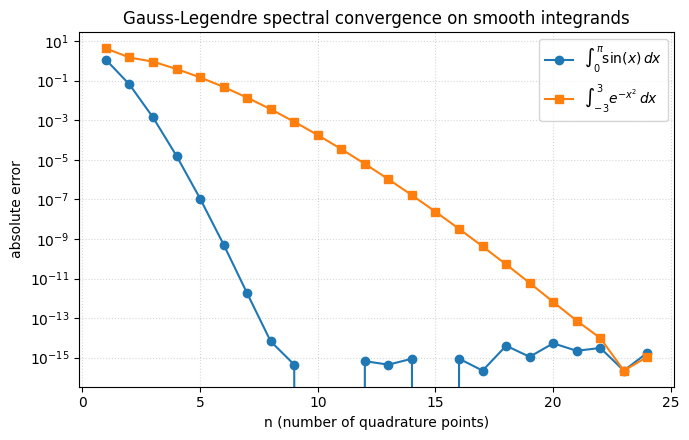

In [9]:
"""Gauss-Legendre quadrature: nodes / weights table + convergence.

Reference: Part 3 §4 (SA-03-52 / RM-03-54, 2003), Table 3.

Prints the ``n = 1, ..., 24`` Gauss-Legendre nodes and weights and
shows convergence of a smooth-function integral as ``n`` increases.
"""

from __future__ import annotations

import math
import os
import sys

import numpy as np

from radia.analytical_formulas import (
    gauss_legendre_integrate,
    gauss_legendre_nodes_weights,
)
from radia.analytical_formulas.gauss_legendre import N_MAX


def main() -> None:
    print("Gauss-Legendre nodes and weights (positive half, n = 1..6):")
    for n in (1, 2, 3, 4, 5, 6):
        x, w = gauss_legendre_nodes_weights(n)
        # Print only the non-negative half (the table is symmetric).
        half = x[x >= -1e-15]
        wh = w[x >= -1e-15]
        print(f"  n = {n}:")
        for xi, wi in zip(half, wh):
            print(f"    x = {xi:+.15f}    w = {wi:.15f}")
    print(f"  ...   table extends to n = {N_MAX}.")
    print()

    # Convergence of a smooth integral.
    # int_0^pi sin(x) dx = 2 ; the n-point rule is exact for polynomials of
    # degree 2 n - 1, and converges spectrally on smooth integrands.
    truth = 2.0
    print("Convergence of int_0^pi sin(x) dx  (truth = 2.0):")
    print(f"  {'n':>3}  {'estimate':>22}  {'abs error':>12}")
    for n in (1, 2, 3, 4, 5, 6, 8, 10, 12, 16):
        val = gauss_legendre_integrate(np.sin, 0.0, math.pi, n=n)
        err = abs(val - truth)
        print(f"  {n:>3}   {val:>22.15f}   {err:.2e}")

    # Plot: error vs n on a log scale.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return
    ns = np.arange(1, N_MAX + 1)
    errs_sin = []
    errs_smooth = []
    for n in ns:
        val_sin = gauss_legendre_integrate(np.sin, 0.0, math.pi, n=n)
        val_smooth = gauss_legendre_integrate(
            lambda x: np.exp(-x ** 2), -3.0, 3.0, n=n
        )
        errs_sin.append(abs(val_sin - 2.0))
        # int_-3^3 exp(-x**2) dx = sqrt(pi) * erf(3)  (very close to sqrt(pi)).
        from scipy.special import erf
        truth_smooth = math.sqrt(math.pi) * erf(3.0)
        errs_smooth.append(abs(val_smooth - truth_smooth))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.semilogy(ns, errs_sin, "o-", lw=1.5, label=r"$\int_0^\pi \sin(x)\, dx$")
    ax.semilogy(ns, errs_smooth, "s-", lw=1.5,
                label=r"$\int_{-3}^{3} e^{-x^2}\, dx$")
    ax.set_xlabel("n (number of quadrature points)")
    ax.set_ylabel("absolute error")
    ax.set_title("Gauss-Legendre spectral convergence on smooth integrands")
    ax.set_yscale("log")
    ax.grid(True, ls=":", alpha=0.5, which="both")
    ax.legend()
    fig.tight_layout()
    out = "gauss_legendre_demo.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Cross-validation: 2D bar vs 3D cuboid

Cross-check the 2D bar formula against radia.analytical_magnet.CuboidMagnet in the long-bar limit (L_z -> inf); O(1/L_z^2) convergence.

*(source: `cross_validation_3d_vs_2d.py`)*

2D bar: 2 a x 2 b = 0.040 x 0.020 m, M = (1.0e+06, 0) A/m
mu_0 * M_x = 1.2566 T

L_z / max(a,b)   |dB|@P0   |dB|@P1   |dB|@P2
         3.0     5.9725e-03  1.5487e-03  6.8486e-03
        10.0     1.7314e-03  1.1738e-03  1.7226e-03
        30.0     2.1858e-04  2.0869e-04  2.1842e-04
       100.0     1.9970e-05  1.9886e-05  1.9969e-05
       300.0     2.2219e-06  2.2208e-06  2.2218e-06



Saved: cross_validation_3d_vs_2d.png


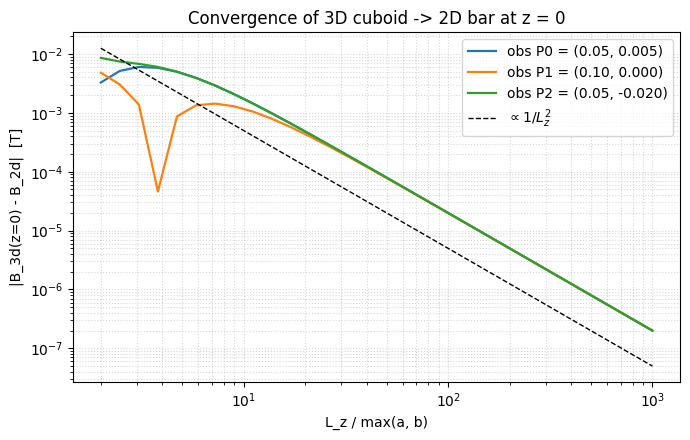

In [10]:
"""Cross-validate the 2D rectangular bar against the 3D cuboid in the
long-bar limit.

The 2D bar formula (Part 2, eq 2-3) is the ``L_z -> infty`` limit of
the 3D ``CuboidMagnet`` field in :mod:`radia.analytical_magnet`. Both
routines accept ``M`` in A/m and return ``B`` in Tesla, so a direct
component-wise compare is meaningful.

The script sweeps the z-extent ``L_z`` of the 3D cuboid and shows the
component-wise convergence rate of ``B_3d(z = 0) - B_2d``. Convergence
should look like ``(max(a, b) / L_z)**2``.
"""

from __future__ import annotations

import os
import sys

import numpy as np

from radia.analytical_formulas import rect_magnet_2d_B
from radia.analytical_formulas.rect_magnet_2d import MU_0
from radia.analytical_magnet import CuboidMagnet


def main() -> None:
    a, b = 0.02, 0.01
    Mx = 1.0e6
    M_3d = [Mx, 0.0, 0.0]

    # Pick observation points along z = 0 outside the cross-section.
    obs_2d = np.array([[0.05, 0.005], [0.10, 0.0], [0.05, -0.02]])

    print(f"2D bar: 2 a x 2 b = {2*a:.3f} x {2*b:.3f} m, M = ({Mx:.1e}, 0) A/m")
    print(f"mu_0 * M_x = {MU_0 * Mx:.4f} T")
    print()

    B_2d_list = [rect_magnet_2d_B(p, a, b, M=(Mx, 0.0)) for p in obs_2d]

    aspects = [3.0, 10.0, 30.0, 100.0, 300.0]
    header = (
        "L_z / max(a,b)" + "".join(f"   |dB|@P{k}" for k in range(len(obs_2d)))
    )
    print(header)
    for L_over_d in aspects:
        Lz = L_over_d * max(a, b)
        cuboid = CuboidMagnet(
            center=[0.0, 0.0, 0.0],
            dimensions=[2 * a, 2 * b, 2 * Lz],
            magnetization=M_3d,
        )
        deltas = []
        for k, (p2, B2) in enumerate(zip(obs_2d, B_2d_list)):
            B3 = np.array(cuboid.get_B([p2[0], p2[1], 0.0]))
            d = float(np.linalg.norm(B3[:2] - B2))
            deltas.append(d)
        ds = "  ".join(f"{d:.4e}" for d in deltas)
        print(f"  {L_over_d:>10.1f}     {ds}")

    # Optional plot.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return
    aspects_plot = np.geomspace(2.0, 1000.0, 30)
    err_per_pt = np.zeros((len(obs_2d), aspects_plot.size))
    for j, asp in enumerate(aspects_plot):
        Lz = asp * max(a, b)
        cuboid = CuboidMagnet(
            center=[0.0, 0.0, 0.0],
            dimensions=[2 * a, 2 * b, 2 * Lz],
            magnetization=M_3d,
        )
        for k, (p2, B2) in enumerate(zip(obs_2d, B_2d_list)):
            B3 = np.array(cuboid.get_B([p2[0], p2[1], 0.0]))
            err_per_pt[k, j] = float(np.linalg.norm(B3[:2] - B2))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for k in range(len(obs_2d)):
        ax.loglog(
            aspects_plot, err_per_pt[k],
            label=f"obs P{k} = ({obs_2d[k][0]:.2f}, {obs_2d[k][1]:.3f})",
            lw=1.6,
        )
    # 1 / L_z**2 reference line.
    ax.loglog(
        aspects_plot, 0.05 / aspects_plot ** 2, "k--", lw=1.0,
        label="$\\propto 1 / L_z^2$",
    )
    ax.set_xlabel("L_z / max(a, b)")
    ax.set_ylabel("|B_3d(z=0) - B_2d|  [T]")
    ax.set_title("Convergence of 3D cuboid -> 2D bar at z = 0")
    ax.grid(True, ls=":", alpha=0.5, which="both")
    ax.legend()
    fig.tight_layout()
    out = "cross_validation_3d_vs_2d.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Cross-validation: solenoid vs current loop

Cross-check the solenoid axial field against the superposed current-loop field.

*(source: `cross_validation_solenoid_currentloop.py`)*

Solenoid: a1 = 50 mm, a2 = 100 mm, b = 100 mm, J = 1.00e+07 A/m**2
Long-coil limit B_inf = 0.6283 T

Closed form B_z(z=0) = 0.502858 T

    (n_r, n_z)    B_z stacked      rel err   time [s]
  (  5,  20)    0.502994    2.703e-04      0.001
  ( 10,  40)    0.502892    6.763e-05      0.003
  ( 20,  80)    0.502867    1.691e-05      0.011
  ( 40, 160)    0.502860    4.228e-06      0.044

Last grid refinement halving error ratio: 4.00 (O(h**2) ideal: 4)

Axial profile comparison (n_r=20, n_z=80):
   z [m]     closed      stacked      rel err
  -0.200   0.05308    0.05307     6.451e-05
  -0.150   0.12392    0.12392     4.021e-05
  -0.100   0.29373    0.29373     5.701e-06
  -0.050   0.45721    0.45722     1.910e-05
  +0.000   0.50286    0.50287     1.691e-05
  +0.050   0.45721    0.45722     1.910e-05
  +0.100   0.29373    0.29373     5.701e-06
  +0.150   0.12392    0.12392     4.021e-05
  +0.200   0.05308    0.05307     6.451e-05



Saved: cross_validation_solenoid_currentloop.png


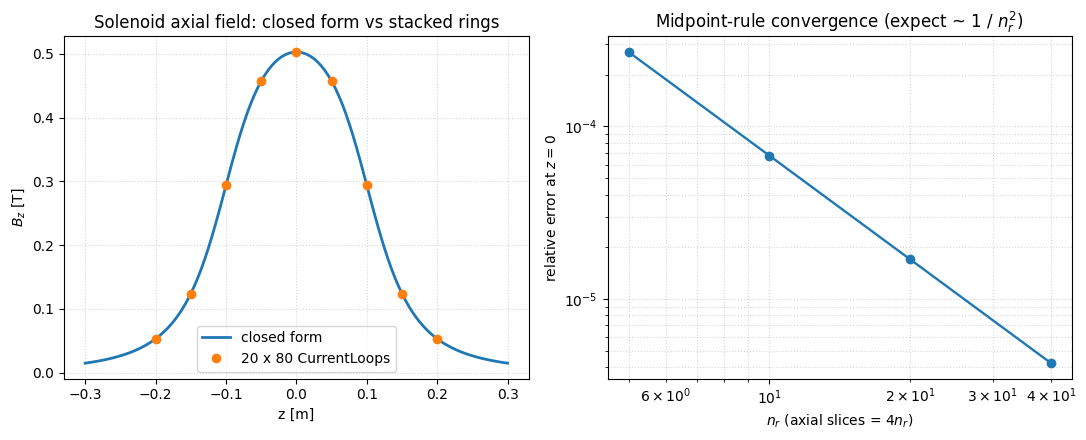

In [11]:
"""Cross-validate the closed-form solenoid axial field against a stacked
set of analytical current loops.

The closed-form `solenoid_axial_field` (Part 4 §4) is the integral of
Biot-Savart over the rectangular cross-section. Numerically the same
quantity is obtained by summing many circular current loops -- here
using `radia.analytical_magnet.CurrentLoop` (Ortner 2022 formulation,
elliptic integrals). Convergence is `O(dr**2 + dz**2)` (midpoint rule).

Both routines accept SI units (m, A, A/m**2, T) so component-wise
compare is meaningful. This is the second cross-validation script,
after `cross_validation_3d_vs_2d.py`.
"""

from __future__ import annotations

import os
import sys
import time

import numpy as np

from radia.analytical_formulas import solenoid_axial_field
from radia.analytical_formulas.solenoid_central import MU_0
from radia.analytical_magnet import CurrentLoop


def stacked_loops_axial_Bz(z_obs, a1, a2, b, J, n_r, n_z):
    dr = (a2 - a1) / n_r
    dz = (2.0 * b) / n_z
    Bz = 0.0
    for i in range(n_r):
        r = a1 + (i + 0.5) * dr
        for k in range(n_z):
            z_ring = -b + (k + 0.5) * dz
            dI = J * dr * dz
            loop = CurrentLoop(
                center=[0.0, 0.0, z_ring],
                diameter=2.0 * r,
                current=dI,
                axis="z",
                units="m",
            )
            Bz += loop.get_B([0.0, 0.0, z_obs])[2]
    return Bz


def main() -> None:
    a1, a2, b, J = 0.05, 0.10, 0.10, 1.0e7
    print(f"Solenoid: a1 = {a1*1000:.0f} mm, a2 = {a2*1000:.0f} mm, "
          f"b = {b*1000:.0f} mm, J = {J:.2e} A/m**2")
    print(f"Long-coil limit B_inf = {MU_0 * J * (a2 - a1):.4f} T")
    print()

    # ----- Convergence study at z = 0 -------------------------------
    z_obs = 0.0
    Bz_ref = float(solenoid_axial_field(z_obs, a1, a2, b, J))
    print(f"Closed form B_z(z=0) = {Bz_ref:.6f} T")
    print()
    print(f"{'(n_r, n_z)':>14} {'B_z stacked':>14} {'rel err':>12} {'time [s]':>10}")
    grids = [(5, 20), (10, 40), (20, 80), (40, 160)]
    Bs, errs, times = [], [], []
    for n_r, n_z in grids:
        t0 = time.perf_counter()
        Bz = stacked_loops_axial_Bz(z_obs, a1, a2, b, J, n_r, n_z)
        dt = time.perf_counter() - t0
        rel_err = abs(Bz - Bz_ref) / Bz_ref
        Bs.append(Bz)
        errs.append(rel_err)
        times.append(dt)
        print(f"  ({n_r:3d}, {n_z:3d})    {Bz:.6f}    {rel_err:.3e}    {dt:7.3f}")
    print()

    # Confirm midpoint rule converges as O(h**2): doubling -> ~ 4x reduction.
    if len(errs) >= 3:
        ratio = errs[-2] / errs[-1]
        print(f"Last grid refinement halving error ratio: {ratio:.2f} "
              f"(O(h**2) ideal: 4)")

    # ----- Axial profile compared, fixed grid ------------------------
    print()
    print("Axial profile comparison (n_r=20, n_z=80):")
    print(f"{'z [m]':>8} {'closed':>10} {'stacked':>12} {'rel err':>12}")
    z_grid = np.linspace(-0.2, 0.2, 9)
    Bz_closed = solenoid_axial_field(z_grid, a1, a2, b, J)
    Bz_num = np.array([
        stacked_loops_axial_Bz(z, a1, a2, b, J, 20, 80) for z in z_grid
    ])
    for z, bc, bn in zip(z_grid, Bz_closed, Bz_num):
        rel = abs(bn - bc) / max(abs(bc), 1e-30)
        print(f"  {z:+.3f}   {bc:.5f}    {bn:.5f}     {rel:.3e}")

    # Plot.
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib not installed -- skipping plot)")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    z_dense = np.linspace(-0.3, 0.3, 121)
    axes[0].plot(z_dense, solenoid_axial_field(z_dense, a1, a2, b, J),
                 lw=2, label="closed form")
    axes[0].plot(z_grid, Bz_num, "o", ms=6, label="20 x 80 CurrentLoops")
    axes[0].set_xlabel("z [m]")
    axes[0].set_ylabel(r"$B_z$ [T]")
    axes[0].set_title("Solenoid axial field: closed form vs stacked rings")
    axes[0].legend()
    axes[0].grid(True, ls=":", alpha=0.5)

    nrs = [g[0] for g in grids]
    axes[1].loglog(nrs, errs, "o-", lw=1.7)
    axes[1].set_xlabel("$n_r$ (axial slices = $4 n_r$)")
    axes[1].set_ylabel("relative error at $z = 0$")
    axes[1].set_title("Midpoint-rule convergence (expect ~ 1 / $n_r^2$)")
    axes[1].grid(True, ls=":", alpha=0.5, which="both")

    fig.tight_layout()
    out = "cross_validation_solenoid_currentloop.png"
    fig.savefig(out, dpi=140)
    print(f"\nSaved: {out}")

main()


## Eddy-current and AC-shielding showcase (Part 6/8/9)

End-to-end Part 6/8/9 story: skin depth + planar surface impedance, cylindrical-conductor Bessel AC impedance, thin-shell AC shielding, plate Joule dissipation, magnetic spherical-shell interior field, average B over a target box.

*(source: `eddy_current_complete.py`)*

In [12]:
"""Eddy-current and AC-shielding showcase.

Combines the Part 6 / 8 / 9 extensions in a single end-to-end story:

1. **Skin depth + planar surface impedance** for a copper plate at 1 kHz.
2. **Cylindrical-conductor AC impedance** sweep (Bessel solution): the
   resistance grows from R_dc as the skin depth shrinks below the
   conductor radius.
3. **Thin-shell AC shielding** of a non-magnetic Cu sphere as a
   function of frequency.
4. **Total Joule dissipation in a thin square plate** via Gauss-Legendre
   integration of the analytic eddy-current field.
5. **Magnetic spherical shell** internal-field decomposition.
6. **Average B over a target box** from a magnetised source box, using
   the numerical-integration path.

Every numerical reference is tagged to the source equation in the
Wakao-Igarashi-Fujiwara-Kameari series (Part 6 / 8 / 9).
"""

from __future__ import annotations

import math
import os
import sys

import numpy as np

from radia.analytical_formulas import (
    average_B_in_box,
    cylinder_ac_impedance,
    cylinder_dc_resistance,
    cylinder_internal_inductance,
    planar_surface_impedance,
    plate_eddy_dissipation,
    shielding_factor_sphere_thin_ac,
    skin_depth,
    spherical_shell_internal_field,
)
from radia.analytical_formulas.shielding import MU_0


def main() -> None:
    sigma_cu = 5.96e7
    print("=" * 72)
    print("(1) Copper @ 1 kHz: skin depth + planar surface impedance")
    print("=" * 72)
    omega = 2.0 * math.pi * 1.0e3
    delta = skin_depth(sigma_cu, omega)
    Z_s = planar_surface_impedance(sigma_cu, omega)
    print(f"  skin depth  delta   = {delta * 1e3:.3f} mm")
    print(f"  surface impedance Z_s = {Z_s:.4e} Ohm  (|Z_s|={abs(Z_s):.4e},"
          f" arg={math.degrees(math.atan2(Z_s.imag, Z_s.real)):.2f} deg)")

    print()
    print("=" * 72)
    print("(2) Cylinder Cu, a = 1 mm, AC impedance frequency sweep")
    print("=" * 72)
    a = 1e-3
    R_dc = cylinder_dc_resistance(a, sigma_cu)
    L_int = cylinder_internal_inductance()
    print(f"  R_dc   = {R_dc:.4e} Ohm/m")
    print(f"  L_int  = {L_int * 1e9:.4f} nH/m  (low-freq internal inductance)")
    print(f"  {'f [Hz]':>10}  {'R [Ohm/m]':>12}  {'X [Ohm/m]':>12}  "
          f"{'R / R_dc':>10}")
    for f in (1, 100, 1e3, 1e4, 1e5, 1e6, 1e8):
        Z = cylinder_ac_impedance(a, sigma_cu, 2 * math.pi * f)
        print(f"  {f:>10.1e}  {Z.real:>12.4e}  {Z.imag:>12.4e}  "
              f"{Z.real / R_dc:>10.2f}")

    print()
    print("=" * 72)
    print("(3) Cu spherical shell AC shielding (a = 5 cm, t = 1 mm)")
    print("=" * 72)
    print(f"  {'f [Hz]':>10}  {'|S|':>10}  {'arg(S) [deg]':>14}")
    for f in (1, 10, 60, 1e3, 1e4):
        S = shielding_factor_sphere_thin_ac(0.05, 1e-3, sigma_cu,
                                            2 * math.pi * f)
        phase_deg = math.degrees(math.atan2(S.imag, S.real))
        print(f"  {f:>10.1e}  {abs(S):>10.4f}  {phase_deg:>14.2f}")

    print()
    print("=" * 72)
    print("(4) Square Cu plate (200 mm side, 1 mm thick), dB/dt = 1 T/s")
    print("=" * 72)
    P = plate_eddy_dissipation(0.10, 0.10, 1e-3, sigma_cu, 1.0)
    print(f"  total instantaneous Joule loss P = {P:.4f} W")
    P10 = plate_eddy_dissipation(0.10, 0.10, 1e-3, sigma_cu, 10.0)
    print(f"  at dB/dt = 10 T/s              = {P10:.2f} W "
          f"(10 x faster ramp -> 100 x dissipation, OK)")

    print()
    print("=" * 72)
    print("(5) Magnetic spherical shell (a = 5 cm, b = 6 cm, mu_r = 1000)")
    print("=" * 72)
    out = spherical_shell_internal_field(1.0, 0.05, 0.06, 1000.0)
    print(f"  H_applied   = 1.0 A/m (unit drive)")
    print(f"  H_hollow    = {out['H_hollow']:.4e} A/m")
    print(f"  H_shell     = {out['H_shell']:.4e} A/m")
    print(f"  M_shell     = {out['M_shell']:.4e} A/m")
    print(f"  M_image     = {out['M_image']:.4e} A m^2")
    print(f"  S = H_hollow / H_applied = {out['S']:.4e}")

    print()
    print("=" * 72)
    print("(6) <B> over a 2 mm cube target offset 5 cm in x from a")
    print("    20 x 20 x 10 mm magnetised cube (NdFeB-like, M_x = 9.55e5 A/m)")
    print("=" * 72)
    src_min = np.array([-0.01, -0.01, -0.005])
    src_max = np.array([+0.01, +0.01, +0.005])
    target_centre = np.array([0.05, 0.0, 0.0])
    half_t = np.array([0.001, 0.001, 0.001])
    B_avg = average_B_in_box(
        [9.55e5, 0.0, 0.0],
        src_min, src_max,
        target_centre - half_t, target_centre + half_t,
        n_quad=6,
    )
    # Compare to dipole far-field
    m = 9.55e5 * np.prod(src_max - src_min)
    d = 0.05
    B_dipole_x = (MU_0 / (4 * math.pi)) * 2 * m / d ** 3
    print(f"  <B>_target = {B_avg}  T")
    print(f"  dipole far-field B_x at d = 5 cm = {B_dipole_x:.4e} T")
    print(f"  near-field ratio = {B_avg[0] / B_dipole_x:.4f}")

main()


(1) Copper @ 1 kHz: skin depth + planar surface impedance
  skin depth  delta   = 2.062 mm
  surface impedance Z_s = 8.1387e-06+8.1387e-06j Ohm  (|Z_s|=1.1510e-05, arg=45.00 deg)

(2) Cylinder Cu, a = 1 mm, AC impedance frequency sweep
  R_dc   = 5.3408e-03 Ohm/m
  L_int  = 50.0000 nH/m  (low-freq internal inductance)
      f [Hz]     R [Ohm/m]     X [Ohm/m]    R / R_dc
     1.0e+00    5.3408e-03    3.1416e-07        1.00
     1.0e+02    5.3408e-03    3.1416e-05        1.00
     1.0e+03    5.3469e-03    3.1398e-04        1.00
     1.0e+04    5.9052e-03    2.9768e-03        1.11
     1.0e+05    1.4389e-02    1.2824e-02        2.69
     1.0e+06    4.2329e-02    4.0927e-02        7.93
     1.0e+08    4.1095e-01    4.0961e-01       76.95

(3) Cu spherical shell AC shielding (a = 5 cm, t = 1 mm)
      f [Hz]         |S|    arg(S) [deg]
     1.0e+00      1.0000           -0.45
     1.0e+01      0.9969           -4.48
     6.0e+01      0.9048          -25.20
     1.0e+03      0.1265          